In [2]:
import torch
import random, os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.append("../..")   # repository root
from compression.models import Encoder_16, Decoder_16, VAE
from compression.spectral import bandpass, isotropic_spectrum

# config
MODEL_DIR  = "../../checkpoints/compression"
SAVE_DIR   = "../../results/compression/uniform_spectral"
DATA_PATH  = "../../data/trajectory_real.npy"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED       = 1
K_HF_LO    = 65
k_dealias  = 85
N_SPECTRA  = 100
SPEC_BATCH = 16
eps        = 1e-30

# colormaps 
cmap_full = sns.color_palette("icefire", as_cmap=True)
cmap_hk   = LinearSegmentedColormap.from_list("rbc", [(0,0,1),(1,1,1),(1,0,0)])

# shared dicts
MODEL_LABELS = {
    "A_lat16_mse":      "Model A — MSE",
    "B_lat16_mse_spec": "Model B — MSE+Spec",
}
STYLES = {
    "A_lat16_mse":      ("#e05c00", "-"),
    "B_lat16_mse_spec": ("#0077bb", "--"),
}
ZONES = {
    "inertial": dict(k_lo=6,  k_hi=40, label="IR", color="#2ca02c"),
    "mid":      dict(k_lo=40, k_hi=65, label="DO", color="#e67e00"),
    "high_k":   dict(k_lo=65, k_hi=85, label="DD", color="#9b0000"),
}

# data
data      = np.load(DATA_PATH)
train_raw = data[1000:5500]
test_raw  = data[5500:6000]
mu, sigma = train_raw.mean(), train_raw.std()
test_norm = (test_raw - mu) / (sigma + 1e-9)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# helpers
def load_model(name):
    vae = VAE(Encoder_16(1, 8), Decoder_16(8, 1)).to(device)
    ck  = torch.load(f"{MODEL_DIR}/best_{name}.pt", map_location=device)
    vae.load_state_dict(ck["model_state"])
    vae.eval()
    return vae

def to_np(t):
    return t[:, 0].cpu().numpy() * sigma + mu

def reconstruct(model, x):
    with torch.no_grad():
        mean_z, _ = model.encoder(x)
        return model.decoder(mean_z)

def add_zones(ax, pad=1.08):
    for z in ZONES.values():
        ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.07, color=z["color"], zorder=0)
        ax.text((z["k_lo"] + z["k_hi"]) / 2, pad, z["label"],
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom",
                fontsize=12, color=z["color"], fontweight="bold")
    ax.axvline(4, color="gray", lw=1.0, ls="--", alpha=0.6)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, which="both", alpha=0.2)

# load models
models = {name: load_model(name) for name in MODEL_LABELS}
print("Models loaded.")

Models loaded.


/tmp/ipykernel_295149/3118657231.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck  = torch.load(f"{MODEL_DIR}/best_{name}.pt", map_location=device)


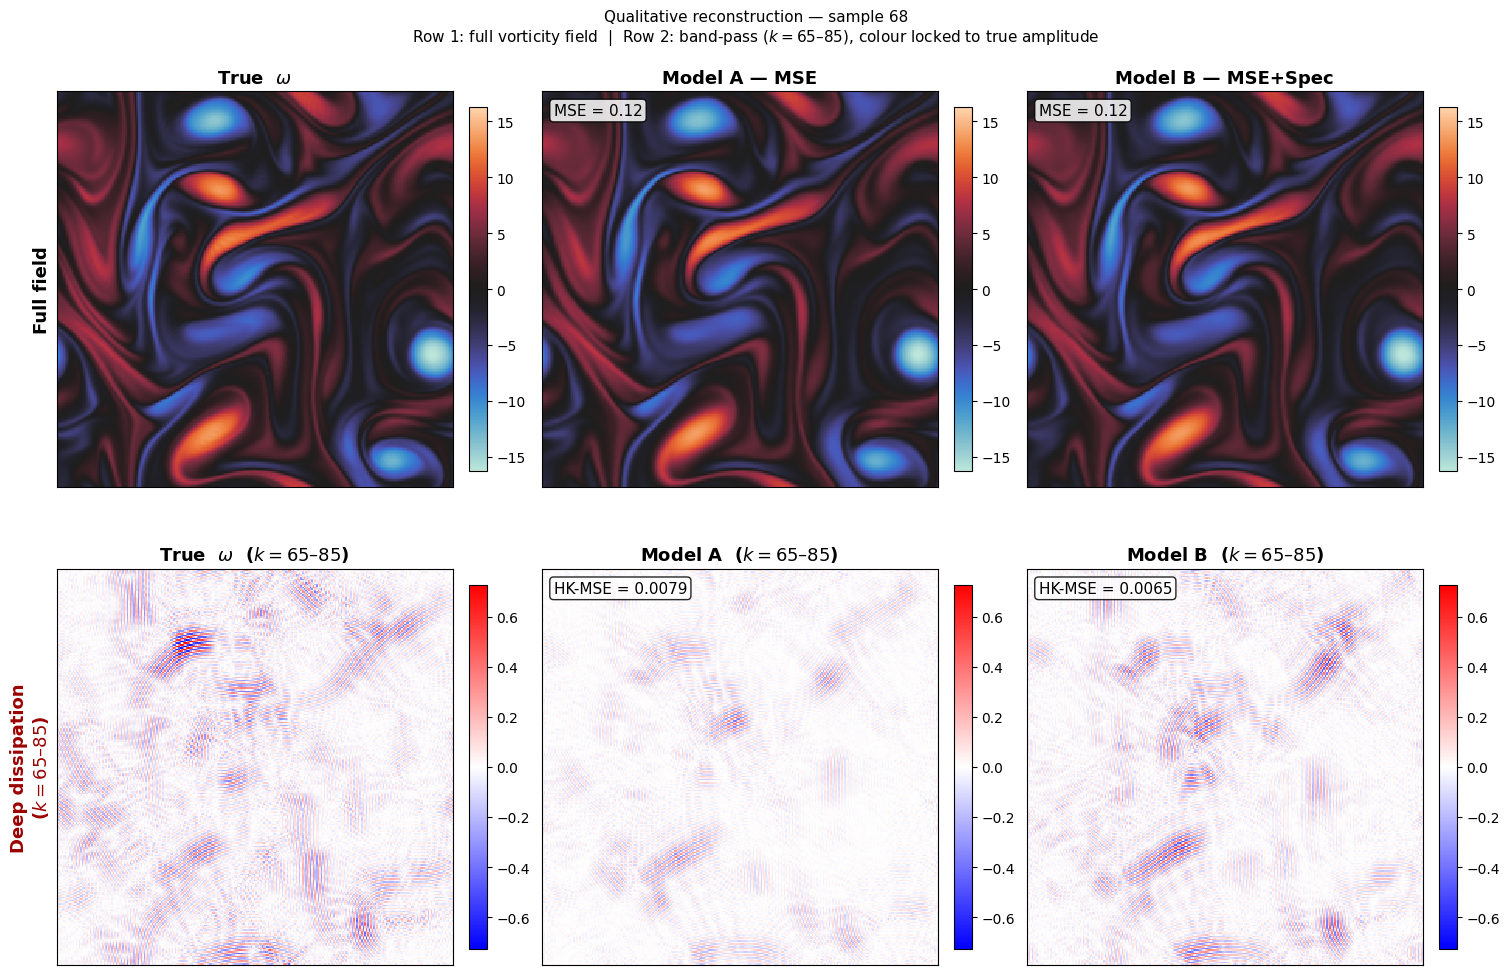

Saved fig4_qualitative.png


In [3]:
# FIGURE 4 — qualitative reconstruction
random.seed(SEED); torch.manual_seed(SEED)
idx     = random.sample(range(len(test_norm)), 1)
samples = torch.tensor(test_norm[idx, None], dtype=torch.float32).to(device)

true_np  = to_np(samples)
recon_A  = to_np(reconstruct(models["A_lat16_mse"],      samples))
recon_B  = to_np(reconstruct(models["B_lat16_mse_spec"], samples))
mse_A    = ((true_np[0] - recon_A[0])**2).mean()
mse_B    = ((true_np[0] - recon_B[0])**2).mean()
true_hk  = bandpass(true_np[0], K_HF_LO, k_dealias)
recA_hk  = bandpass(recon_A[0], K_HF_LO, k_dealias)
recB_hk  = bandpass(recon_B[0], K_HF_LO, k_dealias)
mse_hk_A = ((true_hk - recA_hk)**2).mean()
mse_hk_B = ((true_hk - recB_hk)**2).mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
FS = 13

for col, (field, title, annot) in enumerate([
    (true_np[0], r"True  $\omega$",     None),
    (recon_A[0], "Model A — MSE",       f"MSE = {mse_A:.2g}"),
    (recon_B[0], "Model B — MSE+Spec",  f"MSE = {mse_B:.2g}"),
]):
    ax = axes[0, col]
    im = ax.imshow(field, cmap=cmap_full,
                   vmin=-np.abs(true_np[0]).max(),
                   vmax= np.abs(true_np[0]).max(),
                   origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[], title=title)
    ax.title.set_fontsize(FS); ax.title.set_fontweight("bold")
    if annot:
        ax.text(0.03, 0.97, annot, transform=ax.transAxes, fontsize=11, va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85))
axes[0, 0].set_ylabel("Full field", fontsize=FS, fontweight="bold")

for col, (field, title, annot) in enumerate([
    (true_hk, f"True  $\\omega$  ($k={K_HF_LO}$–$85$)", None),
    (recA_hk, f"Model A  ($k={K_HF_LO}$–$85$)",          f"HK-MSE = {mse_hk_A:.2g}"),
    (recB_hk, f"Model B  ($k={K_HF_LO}$–$85$)",          f"HK-MSE = {mse_hk_B:.2g}"),
]):
    ax = axes[1, col]
    im = ax.imshow(field, cmap=cmap_hk,
                   vmin=-np.abs(true_hk).max(),
                   vmax= np.abs(true_hk).max(),
                   origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[], title=title)
    ax.title.set_fontsize(FS); ax.title.set_fontweight("bold")
    if annot:
        ax.text(0.03, 0.97, annot, transform=ax.transAxes, fontsize=11, va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85))
axes[1, 0].set_ylabel(f"Deep dissipation\n($k={K_HF_LO}$–$85$)",
                      fontsize=FS, fontweight="bold",
                      color=ZONES["high_k"]["color"])
fig.suptitle(
    f"Qualitative reconstruction — sample {idx[0]}\n"
    r"Row 1: full vorticity field  |  "
    f"Row 2: band-pass ($k={K_HF_LO}$–$85$), colour locked to true amplitude",
    fontsize=11)
plt.savefig(f"{SAVE_DIR}/fig4_qualitative.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved fig4_qualitative.png")

Computing spectra for 100 fields ...
Done.



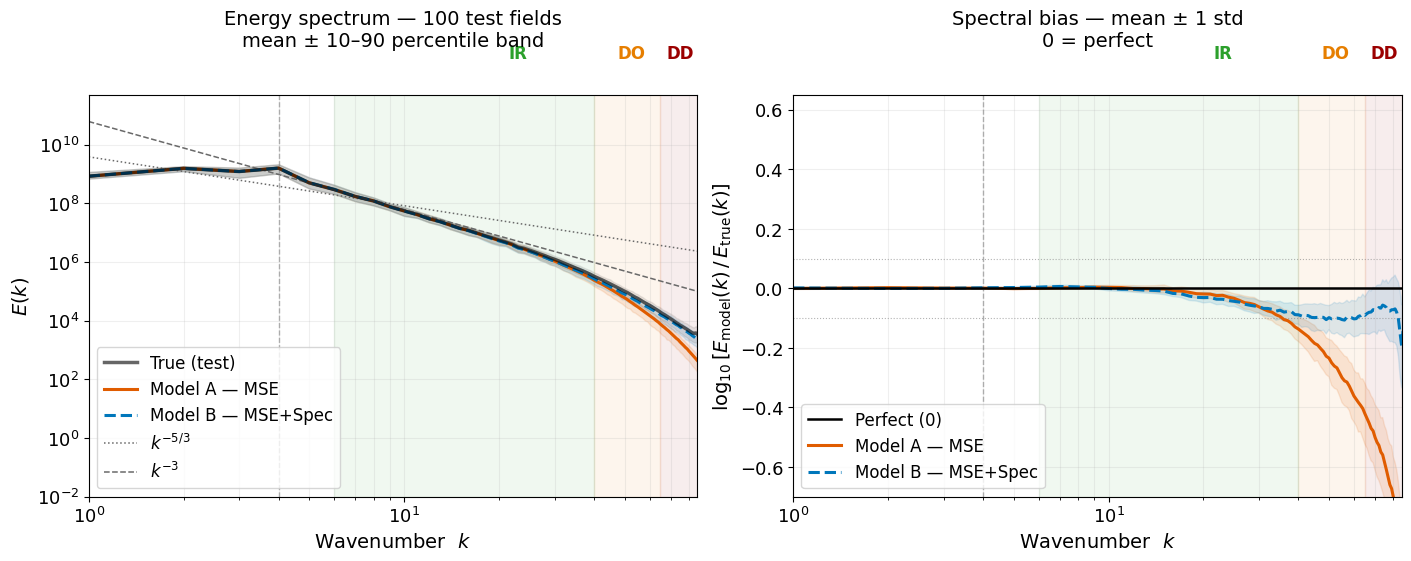

Saved fig5_spectra.png


In [4]:
# FIGURE 5 — ensemble spectra
spec_loader = DataLoader(
    TensorDataset(torch.tensor(test_norm[:N_SPECTRA, None], dtype=torch.float32)),
    batch_size=SPEC_BATCH, shuffle=False)

all_spectra = {"true": [], "A_lat16_mse": [], "B_lat16_mse_spec": []}
print(f"Computing spectra for {N_SPECTRA} fields ...")

with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu
        for i in range(xb.size(0)):
            Ei, k_arr = isotropic_spectrum(xt_np[i])
            all_spectra["true"].append(Ei)
        for name in MODEL_LABELS:
            mz, _ = models[name].encoder(xb)
            xhat  = models[name].decoder(mz)
            xh_np = xhat[:, 0].cpu().numpy() * sigma + mu
            for i in range(xb.size(0)):
                E, _ = isotropic_spectrum(xh_np[i])
                all_spectra[name].append(E)

for key in all_spectra:
    all_spectra[key] = np.stack(all_spectra[key])
print("Done.\n")

Et    = all_spectra["true"]
k_ref = 8
E_ref = np.interp(k_ref, k_arr, Et.mean(0))
k53   = E_ref * (k_arr / k_ref) ** (-5/3)
k3    = E_ref * (k_arr / k_ref) ** (-3.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
FS = 14

ax1.loglog(k_arr, Et.mean(0), color="black", lw=2.5, label="True (test)", zorder=5, alpha=0.6)
ax1.fill_between(k_arr, np.percentile(Et, 10, axis=0),
                 np.percentile(Et, 90, axis=0), color="black", alpha=0.08)
for name in MODEL_LABELS:
    E = all_spectra[name]; c, ls = STYLES[name]
    ax1.loglog(k_arr, E.mean(0), color=c, lw=2.2, ls=ls, label=MODEL_LABELS[name])
    ax1.fill_between(k_arr, np.percentile(E, 10, axis=0),
                     np.percentile(E, 90, axis=0), color=c, alpha=0.12)
ax1.loglog(k_arr, k53, color="dimgray", lw=1.1, ls=":",  label=r"$k^{-5/3}$")
ax1.loglog(k_arr, k3,  color="dimgray", lw=1.1, ls="--", label=r"$k^{-3}$")
add_zones(ax1)
ax1.set_xlim(1, k_dealias); ax1.set_ylim(1e-2, None)
ax1.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax1.set_ylabel("$E(k)$", fontsize=FS)
ax1.set_title(f"Energy spectrum — {N_SPECTRA} test fields\nmean ± 10–90 percentile band",
              fontsize=FS, pad=35)
ax1.legend(fontsize=12, loc="lower left")

ax2.axhline(0,    color="black", lw=1.8, label="Perfect (0)", zorder=5)
ax2.axhline( 0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
ax2.axhline(-0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
for name in MODEL_LABELS:
    E = all_spectra[name]; c, ls = STYLES[name]
    lr = np.log10((E + eps) / (Et + eps))
    ax2.semilogx(k_arr, lr.mean(0), color=c, lw=2.2, ls=ls, label=MODEL_LABELS[name])
    ax2.fill_between(k_arr, lr.mean(0) - lr.std(0),
                     lr.mean(0) + lr.std(0), color=c, alpha=0.12)
add_zones(ax2)
ax2.set_xlim(1, k_dealias); ax2.set_ylim(-0.7, 0.65)
ax2.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax2.set_ylabel(r"$\log_{10}[E_\mathrm{model}(k)\,/\,E_\mathrm{true}(k)]$", fontsize=FS)
ax2.set_title("Spectral bias — mean ± 1 std\n0 = perfect", fontsize=FS, pad=35)
ax2.legend(fontsize=12, loc="lower left")

plt.savefig(f"{SAVE_DIR}/fig5_spectra.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved fig5_spectra.png")

In [5]:
# spectral bias table
ir  = (k_arr >= ZONES["inertial"]["k_lo"]) & (k_arr <= ZONES["inertial"]["k_hi"])
do  = (k_arr >  ZONES["mid"]["k_lo"])      & (k_arr <= ZONES["mid"]["k_hi"])
dd  = (k_arr >  ZONES["high_k"]["k_lo"])   & (k_arr <= ZONES["high_k"]["k_hi"])
ali =  k_arr >  k_dealias

print(f"\n{'Model':<28s}  {'IR bias':>9s}  {'IR sprd':>8s}  "
      f"{'DO bias':>9s}  {'DO sprd':>8s}  "
      f"{'DD bias':>9s}  {'DD sprd':>8s}  {'Alias':>8s}")
print("-" * 105)
for name in MODEL_LABELS:
    lr = np.log10((all_spectra[name] + eps) / (Et + eps))
    print(f"  {MODEL_LABELS[name]:<26s}"
          f"  {lr[:, ir].mean():>+9.4f}  {lr[:, ir].std():>8.4f}"
          f"  {lr[:, do].mean():>+9.4f}  {lr[:, do].std():>8.4f}"
          f"  {lr[:, dd].mean():>+9.4f}  {lr[:, dd].std():>8.4f}"
          f"  {lr[:, ali].mean():>+8.4f}")


Model                           IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd     Alias
---------------------------------------------------------------------------------------------------------
  Model A — MSE                 -0.0415    0.0479    -0.2755    0.1132    -0.6215    0.1883   +0.9539
  Model B — MSE+Spec            -0.0390    0.0364    -0.0978    0.0524    -0.0833    0.1030   +1.4078


Computing swap spectra ...
Done.


Combination                         IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd
----------------------------------------------------------------------------------------------------
  $D_A(E_A)$ — baseline             -0.0415    0.0479    -0.2755    0.1132    -0.6215    0.1883
  $D_B(E_B)$ — full Model B         -0.0390    0.0364    -0.0978    0.0524    -0.0833    0.1030
  $D_A(E_B)$ — B enc, A dec         -0.3981    0.2007    -0.9177    0.1646    -1.1094    0.1386
  $D_B(E_A)$ — A enc, B dec         -0.4010    0.2390    -0.6000    0.1143    -0.5339    0.1567


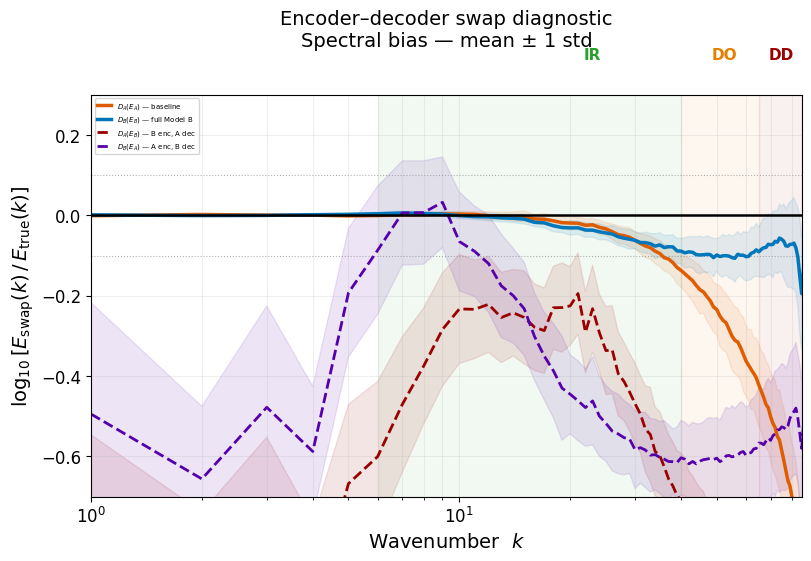

Saved fig_swap_bias.png


In [6]:
# Encoder-Decoder Swap Diagnostic

# load the four components separately
E_A = models["A_lat16_mse"].encoder
D_A = models["A_lat16_mse"].decoder
E_B = models["B_lat16_mse_spec"].encoder
D_B = models["B_lat16_mse_spec"].decoder

# set all to eval
for m in [E_A, D_A, E_B, D_B]:
    m.eval()

# cross-swap forward pass
def cross_reconstruct(encoder, decoder, x_gpu):
    with torch.no_grad():
        mean_z, _ = encoder(x_gpu)
        return decoder(mean_z)

# compute spectra for all four combinations
swap_spectra = {
    "DA_EA": [],   # baseline A          — already in all_spectra but recompute for consistency
    "DB_EB": [],   # baseline B          — same
    "DA_EB": [],   # key probe: B enc, A dec
    "DB_EA": [],   # complementary: A enc, B dec
}

swap_configs = {
    "DA_EA": (E_A, D_A),
    "DB_EB": (E_B, D_B),
    "DA_EB": (E_B, D_A),   # note: encoder first, decoder second
    "DB_EA": (E_A, D_B),
}

swap_labels = {
    "DA_EA": r"$D_A(E_A)$ — baseline",
    "DB_EB": r"$D_B(E_B)$ — full Model B",
    "DA_EB": r"$D_A(E_B)$ — B enc, A dec",
    "DB_EA": r"$D_B(E_A)$ — A enc, B dec",
}

print("Computing swap spectra ...")
with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu

        for key, (enc, dec) in swap_configs.items():
            mean_z, _ = enc(xb)
            xhat      = dec(mean_z)
            xh_np     = xhat[:, 0].cpu().numpy() * sigma + mu
            for i in range(xb.size(0)):
                E, _ = isotropic_spectrum(xh_np[i])
                swap_spectra[key].append(E)

for key in swap_spectra:
    swap_spectra[key] = np.stack(swap_spectra[key])
print("Done.\n")

# spectral bias table
ir = (k_arr >= ZONES["inertial"]["k_lo"]) & (k_arr <= ZONES["inertial"]["k_hi"])
do = (k_arr >  ZONES["mid"]["k_lo"])      & (k_arr <= ZONES["mid"]["k_hi"])
dd = (k_arr >  ZONES["high_k"]["k_lo"])   & (k_arr <= ZONES["high_k"]["k_hi"])

print(f"\n{'Combination':<32s}  {'IR bias':>9s}  {'IR sprd':>8s}  "
      f"{'DO bias':>9s}  {'DO sprd':>8s}  "
      f"{'DD bias':>9s}  {'DD sprd':>8s}")
print("-" * 100)

for key in ["DA_EA", "DB_EB", "DA_EB", "DB_EA"]:
    lr = np.log10((swap_spectra[key] + eps) / (Et + eps))
    print(f"  {swap_labels[key]:<30s}"
          f"  {lr[:, ir].mean():>+9.4f}"
          f"  {lr[:, ir].std():>8.4f}"
          f"  {lr[:, do].mean():>+9.4f}"
          f"  {lr[:, do].std():>8.4f}"
          f"  {lr[:, dd].mean():>+9.4f}"
          f"  {lr[:, dd].std():>8.4f}")

# spectral bias plot — DD zone focus
SWAP_STYLES = {
    "DA_EA": ("#e05c00", "-",  2.5),
    "DB_EB": ("#0077bb", "-",  2.5),
    "DA_EB": ("#9b0000", "--", 2.0),
    "DB_EA": ("#5500aa", "--", 2.0),
}

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

ax.axhline(0,    color="black", lw=1.8, zorder=5)
ax.axhline( 0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
ax.axhline(-0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)

for key in ["DA_EA", "DB_EB", "DA_EB", "DB_EA"]:
    E  = swap_spectra[key]
    c, ls, lw = SWAP_STYLES[key]
    lr = np.log10((E + eps) / (Et + eps))
    ax.semilogx(k_arr, lr.mean(0), color=c, lw=lw, ls=ls,
                label=swap_labels[key])
    ax.fill_between(k_arr,
                    lr.mean(0) - lr.std(0),
                    lr.mean(0) + lr.std(0),
                    color=c, alpha=0.10)

# zone shading
for z in ZONES.values():
    ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.06, color=z["color"], zorder=0)
    ax.text((z["k_lo"] + z["k_hi"]) / 2, 1.08, z["label"],
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=11, color=z["color"], fontweight="bold")

ax.set_xlim(1, k_dealias)
ax.set_ylim(-0.7, 0.3)
ax.set_xlabel("Wavenumber  $k$", fontsize=14)
ax.set_ylabel(r"$\log_{10}[E_\mathrm{swap}(k)\,/\,E_\mathrm{true}(k)]$",
              fontsize=14)
ax.set_title("Encoder–decoder swap diagnostic\nSpectral bias — mean ± 1 std",
             fontsize=14, pad=35)
ax.tick_params(labelsize=12)
ax.grid(True, which="both", alpha=0.2)
ax.legend(fontsize=5, loc="upper left")

plt.savefig(f"{SAVE_DIR}/fig_swap_bias.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_swap_bias.png")